# Geographic Hotspot Analysis - Hexbin Plot Explained
## Understanding the Darkest Spots & Extracting Property Data

In [15]:
# Load data first
df = pd.read_csv('data/edaall.csv')

# Filter for luxury properties for better hotspot visualization
df_luxury = df[(df['grade'] >= 10) & (df['condition'] >= 3)]

print("Dataset Info:")
print(f"Total properties: {len(df)}")
print(f"Luxury properties (Grade 10+, Condition 3+): {len(df_luxury)}")
print(f"\nLatitude range: {df['lat'].min():.4f} to {df['lat'].max():.4f}")
print(f"Longitude range: {df['long'].min():.4f} to {df['long'].max():.4f}")
print(f"Price range: ${df['price'].min():,.0f} to ${df['price'].max():,.0f}")

Dataset Info:
Total properties: 21597
Luxury properties (Grade 10+, Condition 3+): 1633

Latitude range: 47.1559 to 47.7776
Longitude range: -122.5190 to -121.3150
Price range: $78,000 to $7,700,000


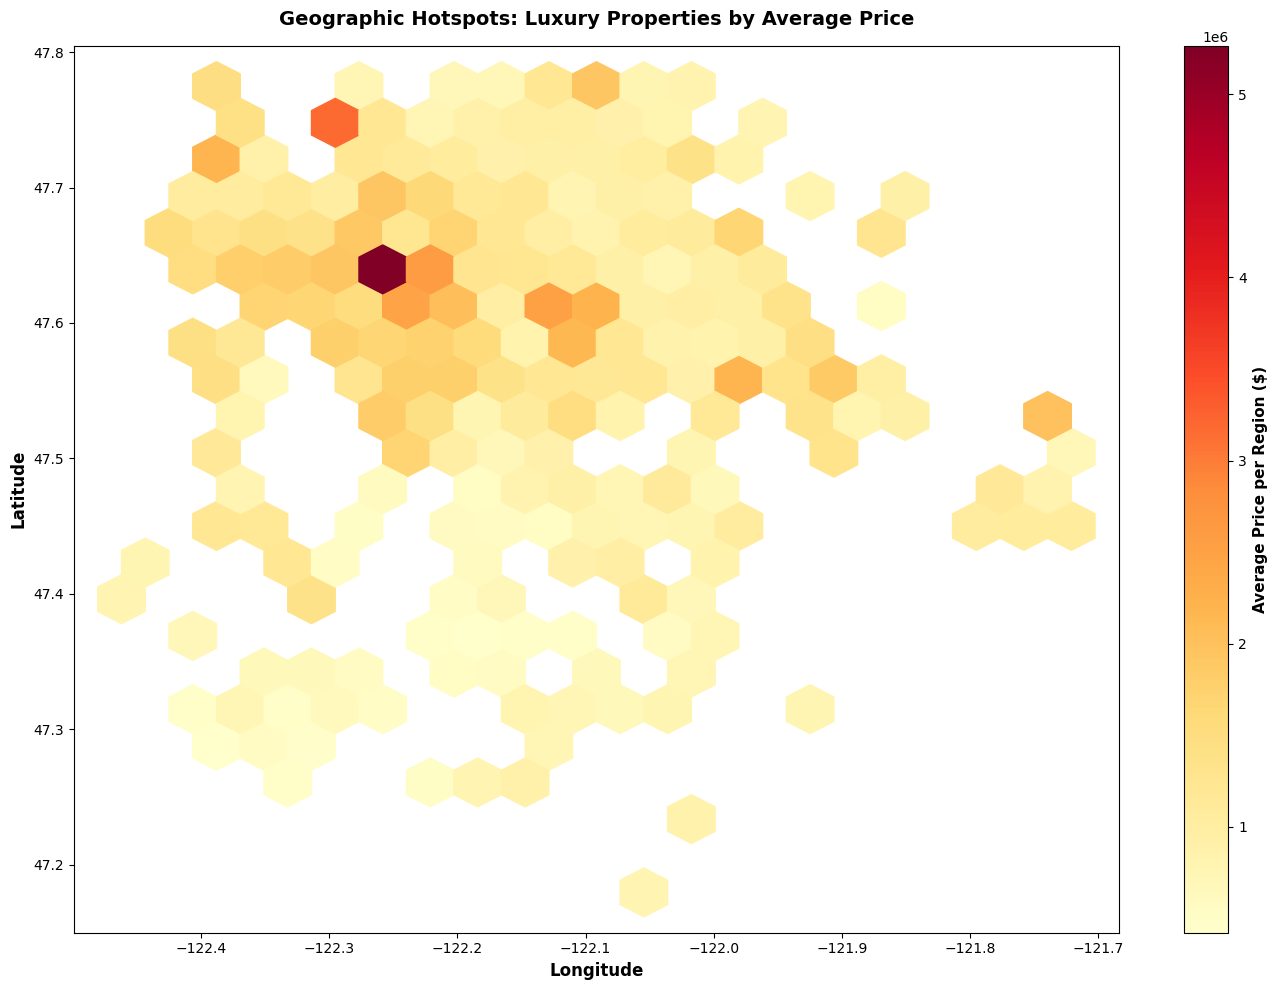


HEXBIN PLOT EXPLANATION

📍 WHAT EACH COLOR MEANS:
   • YELLOW hexagons = Lower average prices in that geographic region
   • ORANGE hexagons = Medium average prices
   • DARK RED hexagons = HIGHEST average prices (LUXURY HOTSPOTS!)

🎯 DARKEST RED SPOTS INDICATE:
   • Geographic clusters with the most expensive properties
   • Neighborhoods commanding premium prices
   • Best neighborhoods for luxury investors like Jennifer


In [17]:
# --- HEXBIN PLOT: Geographic Hotspots by Price ---
import numpy as np

fig, ax = plt.subplots(figsize=(14, 10))

# Create hexbin plot
hexbin = ax.hexbin(
    df_luxury['long'], 
    df_luxury['lat'], 
    C=df_luxury['price'],  # Color by price
    gridsize=20,           # Number of hexagons
    cmap='YlOrRd',         # Yellow → Orange → Red (low → high price)
    mincnt=1,              # Minimum count per hex
    reduce_C_function=np.mean  # Use MEAN price per hex
)

ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
ax.set_title('Geographic Hotspots: Luxury Properties by Average Price', 
             fontsize=14, fontweight='bold', pad=15)

cbar = plt.colorbar(hexbin, ax=ax)
cbar.set_label('Average Price per Region ($)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("HEXBIN PLOT EXPLANATION")
print("="*80)
print("\n📍 WHAT EACH COLOR MEANS:")
print("   • YELLOW hexagons = Lower average prices in that geographic region")
print("   • ORANGE hexagons = Medium average prices")
print("   • DARK RED hexagons = HIGHEST average prices (LUXURY HOTSPOTS!)")
print("\n🎯 DARKEST RED SPOTS INDICATE:")
print("   • Geographic clusters with the most expensive properties")
print("   • Neighborhoods commanding premium prices")
print("   • Best neighborhoods for luxury investors like Jennifer")

In [18]:
# --- EXTRACT HOTSPOT REGIONS FROM HEXBIN DATA ---
print("\n" + "="*80)
print("STEP 1: IDENTIFY HOTSPOT REGIONS")
print("="*80)

# Calculate average price per geographic area (by rounding coordinates)
# This approximates the hexbin grid
df_luxury['lat_bin'] = pd.cut(df_luxury['lat'], bins=20)
df_luxury['long_bin'] = pd.cut(df_luxury['long'], bins=20)

# Group by bins to find high-price regions
region_analysis = df_luxury.groupby(['lat_bin', 'long_bin']).agg({
    'price': ['mean', 'count', 'max'],
    'grade': 'mean',
    'condition': 'mean'
}).round(0)

region_analysis.columns = ['avg_price', 'count', 'max_price', 'avg_grade', 'avg_condition']
region_analysis = region_analysis.sort_values('avg_price', ascending=False)

# Show top 5 hotspot regions
print("\nTOP 5 HOTSPOT REGIONS (by average price):")
print(region_analysis.head())

# Extract the MOST EXPENSIVE region (darkest red spot)
top_region = region_analysis.index[0]
lat_range = top_region[0]
long_range = top_region[1]

print(f"\n🔴 DARKEST RED SPOT (Most Expensive Region):")
print(f"   Latitude range:  {lat_range.left:.4f} to {lat_range.right:.4f}")
print(f"   Longitude range: {long_range.left:.4f} to {long_range.right:.4f}")
print(f"   Average Price:   ${region_analysis.iloc[0]['avg_price']:,.0f}")
print(f"   Properties:      {int(region_analysis.iloc[0]['count'])} homes")
print(f"   Avg Grade:       {region_analysis.iloc[0]['avg_grade']:.1f}")
print(f"   Avg Condition:   {region_analysis.iloc[0]['avg_condition']:.1f}")


STEP 1: IDENTIFY HOTSPOT REGIONS

TOP 5 HOTSPOT REGIONS (by average price):
                                        avg_price  count   max_price  \
lat_bin          long_bin                                              
(47.626, 47.656] (-122.277, -122.24]  5265000.000      2 6890000.000   
(47.596, 47.626] (-122.129, -122.092] 2810000.000      4 3300000.000   
                 (-122.24, -122.203]  2542750.000     40 5350000.000   
(47.626, 47.656] (-122.24, -122.203]  2402703.000     37 7060000.000   
(47.656, 47.686] (-122.24, -122.203]  2028750.000      8 5110000.000   

                                       avg_grade  avg_condition  
lat_bin          long_bin                                        
(47.626, 47.656] (-122.277, -122.24]      12.000          4.000  
(47.596, 47.626] (-122.129, -122.092]     11.000          4.000  
                 (-122.24, -122.203]      11.000          3.000  
(47.626, 47.656] (-122.24, -122.203]      11.000          3.000  
(47.656, 47.686] (-122

In [19]:
# --- FETCH PROPERTIES FROM HOTSPOT USING SQL ---
print("\n" + "="*80)
print("STEP 2: GENERATE SQL QUERY FOR HOTSPOT REGION")
print("="*80)

# Extract coordinate bounds from the top region
lat_min = lat_range.left
lat_max = lat_range.right
long_min = long_range.left
long_max = long_range.right

# Generate SQL query for this hotspot region
sql_hotspot_query = f"""
SELECT 
    kchd.id,
    kchs.price,
    kchd.grade,
    kchd.condition,
    kchd.sqft_above,
    kchd.lat,
    kchd.long,
    kchd.yr_built,
    kchd.yr_renovated
FROM eda.king_county_house_details kchd
FULL JOIN eda.king_county_house_sales kchs ON kchs.house_id = kchd.id
WHERE 
    kchd.lat BETWEEN {lat_min:.4f} AND {lat_max:.4f}
    AND kchd.long BETWEEN {long_min:.4f} AND {long_max:.4f}
    AND kchd.grade >= 10
    AND kchd.condition >= 3
ORDER BY kchs.price DESC;
"""

print("\n📋 SQL QUERY FOR HOTSPOT REGION:")
print(sql_hotspot_query)

# Demonstrate with pandas (using CSV data)
print("\n" + "="*80)
print("STEP 3: EXTRACT PROPERTIES FROM HOTSPOT (Using CSV Data)")
print("="*80)

properties_in_hotspot = df_luxury[
    (df_luxury['lat'] >= lat_min) & 
    (df_luxury['lat'] <= lat_max) &
    (df_luxury['long'] >= long_min) & 
    (df_luxury['long'] <= long_max)
].copy()

print(f"\n✓ Found {len(properties_in_hotspot)} luxury properties in this hotspot region")
print(f"\nTop 10 Most Expensive Properties in Hotspot:")
print(properties_in_hotspot[['price', 'grade', 'condition', 'sqft_above', 'lat', 'long']]\
    .sort_values('price', ascending=False).head(10).to_string())

print(f"\nHotspot Property Statistics:")
print(f"  • Average Price:    ${properties_in_hotspot['price'].mean():,.0f}")
print(f"  • Median Price:     ${properties_in_hotspot['price'].median():,.0f}")
print(f"  • Price Range:      ${properties_in_hotspot['price'].min():,.0f} - ${properties_in_hotspot['price'].max():,.0f}")
print(f"  • Average Grade:    {properties_in_hotspot['grade'].mean():.1f}")
print(f"  • Average Size:     {properties_in_hotspot['sqft_above'].mean():,.0f} sqft")


STEP 2: GENERATE SQL QUERY FOR HOTSPOT REGION

📋 SQL QUERY FOR HOTSPOT REGION:

SELECT 
    kchd.id,
    kchs.price,
    kchd.grade,
    kchd.condition,
    kchd.sqft_above,
    kchd.lat,
    kchd.long,
    kchd.yr_built,
    kchd.yr_renovated
FROM eda.king_county_house_details kchd
FULL JOIN eda.king_county_house_sales kchs ON kchs.house_id = kchd.id
WHERE 
    kchd.lat BETWEEN 47.6260 AND 47.6560
    AND kchd.long BETWEEN -122.2770 AND -122.2400
    AND kchd.grade >= 10
    AND kchd.condition >= 3
ORDER BY kchs.price DESC;


STEP 3: EXTRACT PROPERTIES FROM HOTSPOT (Using CSV Data)

✓ Found 3 luxury properties in this hotspot region

Top 10 Most Expensive Properties in Hotspot:
         price  grade  condition  sqft_above    lat     long
2  6890000.000     13          3    8860.000 47.630 -122.240
16 3650000.000     11          5    3910.000 47.651 -122.277
19 3640000.000     11          4    4830.000 47.641 -122.241

Hotspot Property Statistics:
  • Average Price:    $4,726,667
  • 

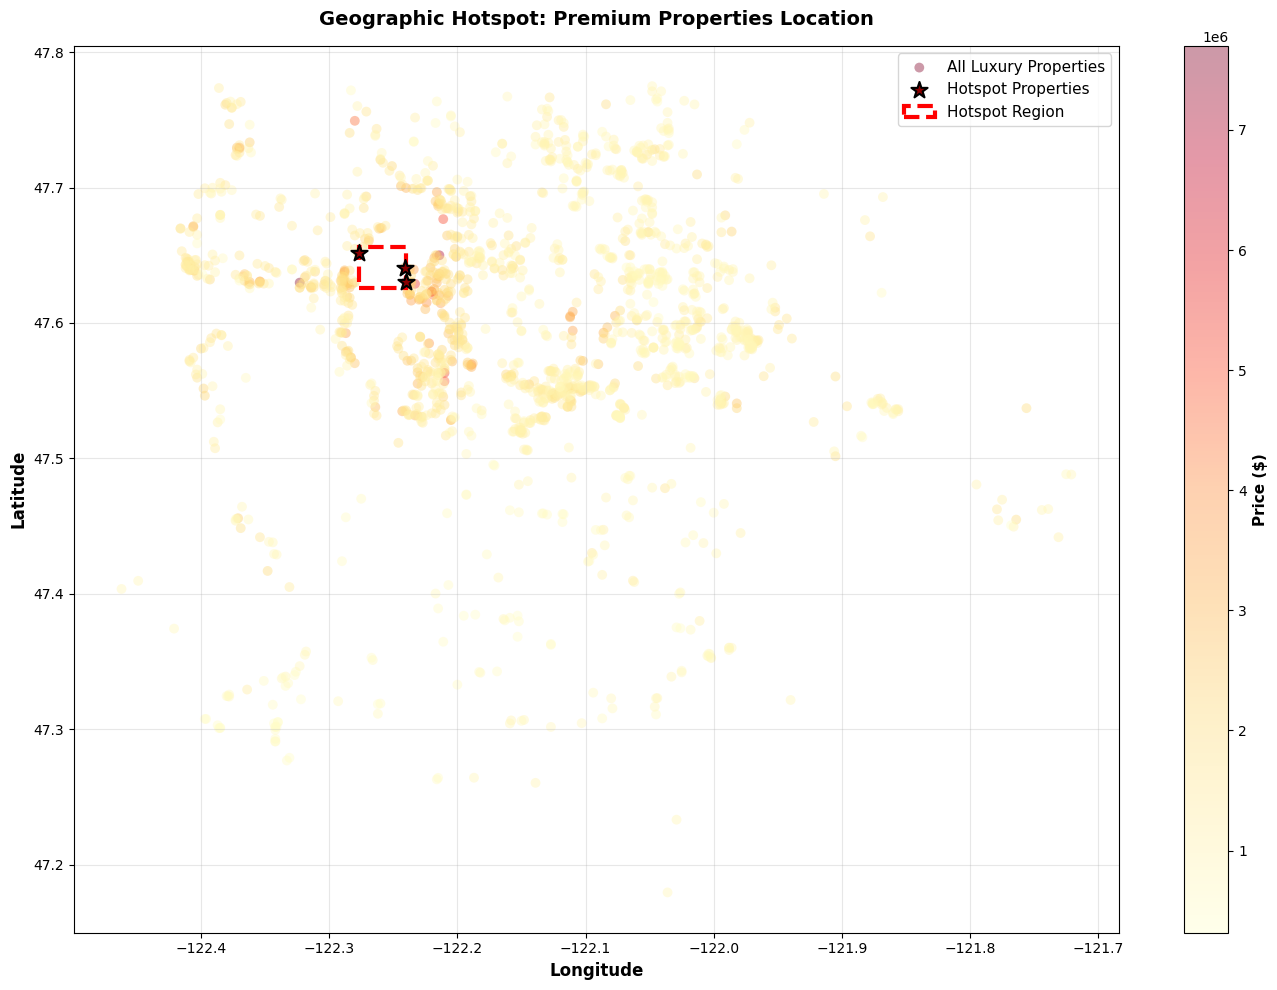


SUMMARY: USING HEXBIN HOTSPOTS FOR INVESTMENT STRATEGY

✅ WORKFLOW USED:
   1. Create hexbin plot to visualize geographic price distribution
   2. Identify DARKEST RED spots = Most expensive neighborhoods
   3. Extract coordinate bounds from hotspot
   4. Write SQL query filtering by lat/long AND grade/condition
   5. Fetch curated list of investment properties in premium zones

📍 FOR JENNIFER'S STRATEGY:
   • Focus on properties in RED hotspots (highest prices)
   • These neighborhoods have strong resale demand
   • Properties here maintain value better (less price volatility)
   • Grade + Condition + Location = TRIPLE PREMIUM for quick resale ✓


In [20]:
# --- VISUALIZE HOTSPOT REGION ON MAP ---
fig, ax = plt.subplots(figsize=(14, 10))

# Plot all luxury properties
scatter_all = ax.scatter(
    df_luxury['long'], 
    df_luxury['lat'], 
    c=df_luxury['price'],
    s=50,
    cmap='YlOrRd',
    alpha=0.4,
    label='All Luxury Properties',
    edgecolors='none'
)

# Highlight hotspot properties in BRIGHT RED
ax.scatter(
    properties_in_hotspot['long'],
    properties_in_hotspot['lat'],
    c='darkred',
    s=150,
    marker='*',
    edgecolors='black',
    linewidth=1.5,
    label='Hotspot Properties',
    zorder=5
)

# Draw bounding box around hotspot
from matplotlib.patches import Rectangle
rect = Rectangle(
    (long_min, lat_min),
    long_max - long_min,
    lat_max - lat_min,
    linewidth=3,
    edgecolor='red',
    facecolor='none',
    linestyle='--',
    label='Hotspot Region'
)
ax.add_patch(rect)

ax.set_xlabel('Longitude', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude', fontsize=12, fontweight='bold')
ax.set_title('Geographic Hotspot: Premium Properties Location', 
             fontsize=14, fontweight='bold', pad=15)
ax.legend(fontsize=11, loc='best')
ax.grid(True, alpha=0.3)

cbar = plt.colorbar(scatter_all, ax=ax)
cbar.set_label('Price ($)', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("SUMMARY: USING HEXBIN HOTSPOTS FOR INVESTMENT STRATEGY")
print("="*80)
print("\n✅ WORKFLOW USED:")
print("   1. Create hexbin plot to visualize geographic price distribution")
print("   2. Identify DARKEST RED spots = Most expensive neighborhoods")
print("   3. Extract coordinate bounds from hotspot")
print("   4. Write SQL query filtering by lat/long AND grade/condition")
print("   5. Fetch curated list of investment properties in premium zones")
print("\n📍 FOR JENNIFER'S STRATEGY:")
print("   • Focus on properties in RED hotspots (highest prices)")
print("   • These neighborhoods have strong resale demand")
print("   • Properties here maintain value better (less price volatility)")
print("   • Grade + Condition + Location = TRIPLE PREMIUM for quick resale ✓")

# EDA

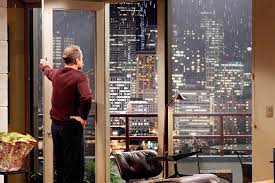

Target customer is Jennifer Montgomery. She wants High budget, wants to show off, timing within a month, waterfront, renovated, high grades, resell within 1 year

I have imported the list of houses based on budget, size, year of construction etc to match her requirements

In [1]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

plt.rcParams.update(
    {"figure.figsize": (8, 5), "axes.facecolor": "white", "axes.edgecolor": "black"}
)
plt.rcParams["figure.facecolor"] = "w"
pd.plotting.register_matplotlib_converters()
pd.set_option("display.float_format", lambda x: "%.3f" % x)

Importing the csv files from postgresql

In [2]:
import pandas as pd
import psycopg2

import os
from dotenv import load_dotenv

load_dotenv()

DATABASE = os.getenv("DATABASE")
USER_DB = os.getenv("USER_DB")
PASSWORD = os.getenv("PASSWORD")
HOST = os.getenv("HOST")
PORT = os.getenv("PORT")

print(PORT if PORT != 0 else 'Error in connection')

5432


In [4]:
# Create connection object conn
conn = psycopg2.connect(
    database=DATABASE, user=USER_DB, password=PASSWORD, host=HOST, port=PORT
)

cur = conn.cursor()

In [47]:
# import the complete data into a pandas dataframe to plot hypothesis
query_string = """
SELECT 
    *
FROM eda.king_county_house_sales kchs
FULL JOIN eda.king_county_house_details kchd 
    ON kchd.id = kchs.house_id
ORDER BY kchs.price DESC
"""
df_psycopg = pd.read_sql(query_string, conn)

In [33]:
# import the data into a pandas dataframe
query_jennifer = """
SELECT 
    kchs.house_id,
    kchs.price,
    kchd.sqft_above,
    kchd.sqft_basement,
    kchd.yr_renovated,
    kchd.grade,
    kchd.condition,
    kchd.waterfront,
    kchd.lat,
    kchd.long
FROM eda.king_county_house_sales kchs
FULL JOIN eda.king_county_house_details kchd 
    ON kchd.id = kchs.house_id
WHERE 
    kchd.waterfront = 1           -- Waterfront only
    AND kchd.grade >= 9           -- High grades
    AND kchd.condition >= 3       -- Good condition
    AND kchd.sqft_above > 2500    -- Spacious
    AND kchd.yr_renovated >= 2015 -- Recently renovated (or new)
    AND kchs.price >= 500000      -- High budget
ORDER BY kchs.price DESC
"""
df_psycopg = pd.read_sql(query_jennifer, conn)

In [5]:
# close the connection
conn.close()

In [50]:
df_psycopg.head()

,date,price,house_id,id,id,bedrooms,bathrooms,sqft_living,sqft_lot,floors,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13,7700000.000,6762700020,7246,6762700020,6.000,8.000,12050.000,27600.000,2.500,...,13,8570.000,3480.000,1910,19870.000,98102,47.630,-122.323,3940.000,8800.000
1,2014-06-11,7060000.000,9808700762,3911,9808700762,5.000,4.500,10040.000,37325.000,2.000,...,11,7680.000,2360.000,1940,20010.000,98004,47.650,-122.214,3930.000,25449.000
2,2014-09-19,6890000.000,9208900037,9246,9208900037,6.000,7.750,9890.000,31374.000,2.000,...,13,8860.000,1030.000,2001,0.000,98039,47.630,-122.240,4540.000,42730.000
3,2014-08-04,5570000.000,2470100110,4408,2470100110,5.000,5.750,9200.000,35069.000,2.000,...,13,6200.000,3000.000,2001,NaN,98039,47.629,-122.233,3560.000,24345.000
4,2015-04-13,5350000.000,8907500070,1447,8907500070,5.000,5.000,8000.000,23985.000,2.000,...,12,6720.000,1280.000,2009,0.000,98004,47.623,-122.220,4600.000,21750.000


In [49]:
# export the complete data to a csv-file
df_psycopg.to_csv("data/edaall.csv", index=False)

In [38]:
# export the data to a csv-file
df_psycopg.to_csv("data/eda.csv", index=False)

In [55]:
#Code begins here for the assignment
# --- Load the Kings county housing dataset ---
# The CSV is stored locally in the data/ folder
df = pd.read_csv('data/eda.csv')
df.shape
#df.info()
df['yr_renovated'] = (df['yr_renovated'] / 10).astype('Int64')
df.head()


,house_id,price,sqft_above,sqft_basement,yr_renovated,grade,condition,waterfront,lat,long
0,9808700762,7060000.000,7680.000,2360.000,2001,11,3,1.000,47.650,-122.214
1,1924059029,4670000.000,4820.000,4820.000,2009,12,3,1.000,47.557,-122.210
2,4114601570,3600000.000,3420.000,1600.000,2002,10,3,1.000,47.593,-122.287
3,5442300807,2700000.000,3831.000,0.000,1980,9,3,1.000,47.592,-122.251
4,9201300050,1850000.000,2800.000,0.000,2001,9,3,1.000,47.578,-122.076


In [6]:
#Code begins here for the assignment
# --- Load the Kings county housing dataset ---
# The CSV is stored locally in the data/ folder
df = pd.read_csv('data/edaall.csv')
df.shape
#df.info()
df['yr_renovated'] = (df['yr_renovated'] / 10).astype('Int64')
df.head()


,date,price,house_id,id,id.1,bedrooms,bathrooms,sqft_living,sqft_lot,floors,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,2014-10-13,7700000.000,6762700020,7246,6762700020,6.000,8.000,12050.000,27600.000,2.500,...,13,8570.000,3480.000,1910,1987,98102,47.630,-122.323,3940.000,8800.000
1,2014-06-11,7060000.000,9808700762,3911,9808700762,5.000,4.500,10040.000,37325.000,2.000,...,11,7680.000,2360.000,1940,2001,98004,47.650,-122.214,3930.000,25449.000
2,2014-09-19,6890000.000,9208900037,9246,9208900037,6.000,7.750,9890.000,31374.000,2.000,...,13,8860.000,1030.000,2001,0,98039,47.630,-122.240,4540.000,42730.000
3,2014-08-04,5570000.000,2470100110,4408,2470100110,5.000,5.750,9200.000,35069.000,2.000,...,13,6200.000,3000.000,2001,<NA>,98039,47.629,-122.233,3560.000,24345.000
4,2015-04-13,5350000.000,8907500070,1447,8907500070,5.000,5.000,8000.000,23985.000,2.000,...,12,6720.000,1280.000,2009,0,98004,47.623,-122.220,4600.000,21750.000


In [64]:
#Code begins here for the assignment
# --- Load the Kings county housing dataset ---
# The CSV is stored locally in the data/ folder
df = pd.read_csv('data/eda.csv')
df.shape
#df.info()
df['yr_renovated'] = (df['yr_renovated'] / 10).astype('Int64')
df.head()


,house_id,price,sqft_above,sqft_basement,yr_renovated,grade,condition,waterfront,lat,long
0,9808700762,7060000.000,7680.000,2360.000,2001,11,3,1.000,47.650,-122.214
1,1924059029,4670000.000,4820.000,4820.000,2009,12,3,1.000,47.557,-122.210
2,4114601570,3600000.000,3420.000,1600.000,2002,10,3,1.000,47.593,-122.287
3,5442300807,2700000.000,3831.000,0.000,1980,9,3,1.000,47.592,-122.251
4,9201300050,1850000.000,2800.000,0.000,2001,9,3,1.000,47.578,-122.076


After we fetched two set of data. one with all available houses and one narrowed down as per client request
#Next we will plot the data as per hypothesis to narrow down the values towards our final result

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

print('Libraries loaded successfully!')
print(f'  pandas  : {pd.__version__}')
print(f'  seaborn : {sns.__version__}')
import matplotlib; print(f'  matplotlib: {matplotlib.__version__}')
import plotly; print(f'  plotly  : {plotly.__version__}')

Libraries loaded successfully!
  pandas  : 2.2.3
  seaborn : 0.13.2
  matplotlib: 3.10.8
  plotly  : 6.7.0


In [7]:
# --- Load the Palmer Penguins dataset ---
# The CSV is stored locally in the data/ folder
df_all = pd.read_csv('data/edaall.csv')


In [62]:
# --- Check for missing values ---
# Missing values can silently affect plots, so always check first
missing = df.isna().sum()
print('Missing values per column:')
print(missing[missing > 0] if missing.sum() > 0 else 'ZERO — clean dataset!')

Missing values per column:
ZERO — clean dataset!


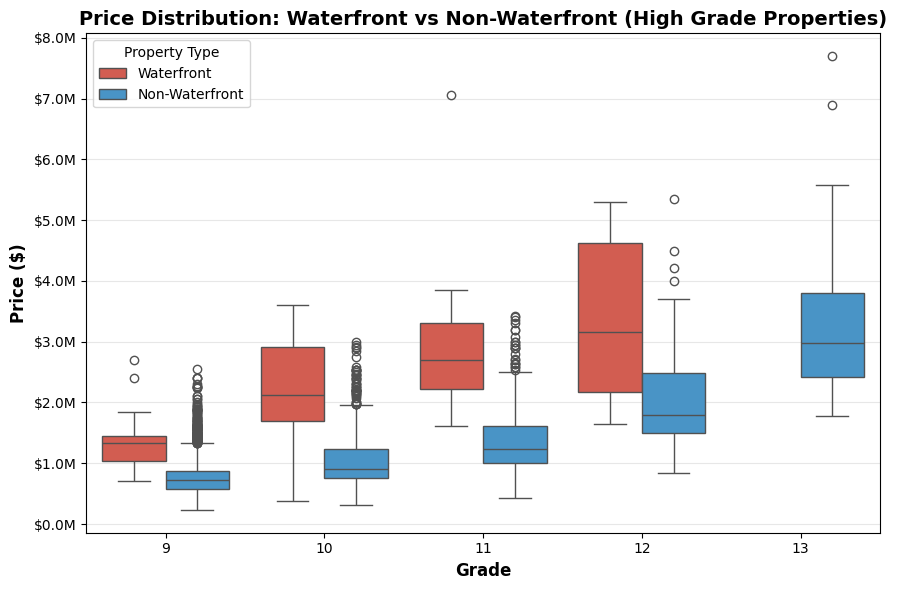

In [73]:
# --- Axes-level scatter: bill length vs flipper length, coloured by species ---
# Box plot samples.
fig, ax = plt.subplots(figsize=(9, 6))

# Prepare data for waterfront premium properties (Grade >= 9)
premium_data = df_all[df_all['grade'] >= 9].copy()
premium_data['Type'] = premium_data['waterfront'].map({1: 'Waterfront', 0: 'Non-Waterfront'})

sns.boxplot(
    data=premium_data,
    x='grade',
    y='price',
    hue='Type',
    palette={'Waterfront': '#e74c3c', 'Non-Waterfront': '#3498db'},
    ax=ax
)

ax.set_title('Price Distribution: Waterfront vs Non-Waterfront (High Grade Properties)', fontsize=14, fontweight='bold')
ax.set_xlabel('Grade', fontsize=12, fontweight='bold')
ax.set_ylabel('Price ($)', fontsize=12, fontweight='bold')
ax.legend(title='Property Type', fontsize=10)
ax.grid(True, alpha=0.3, axis='y')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

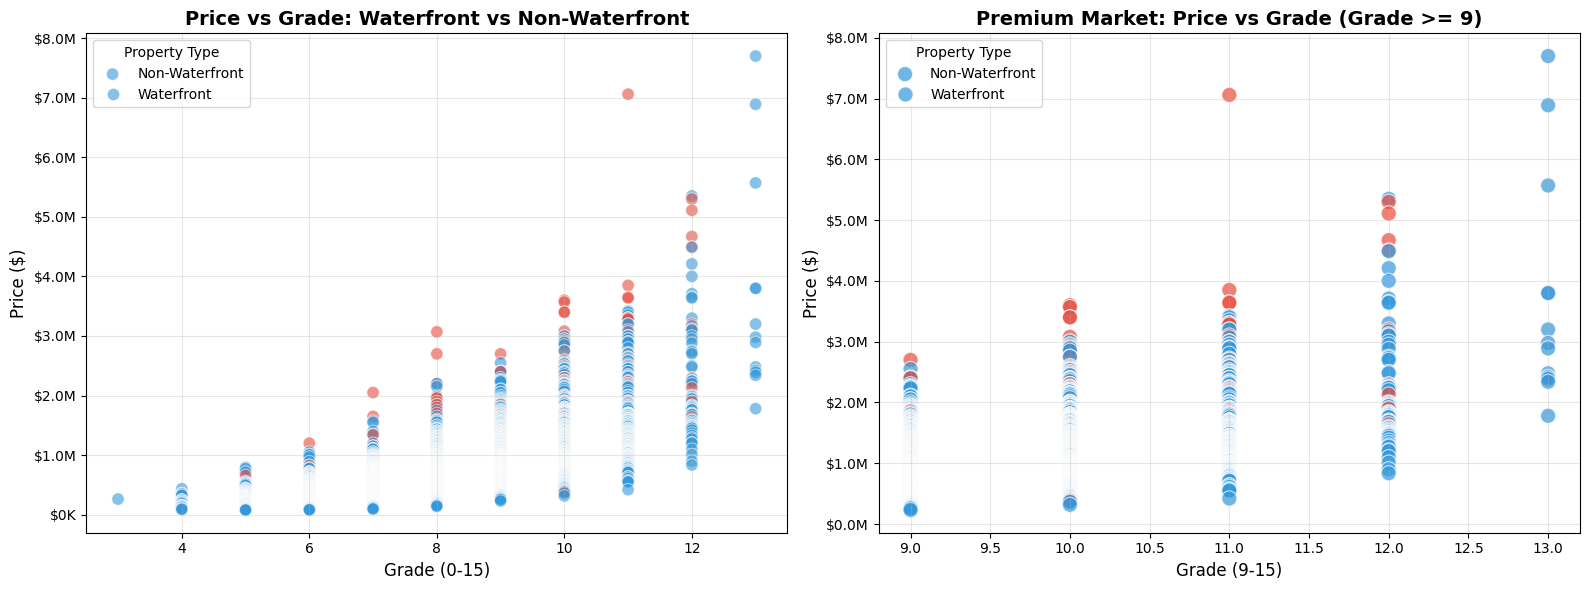

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left plot: All properties
sns.scatterplot(
    data=df_all,
    x='grade',
    y='price',
    hue='waterfront',
    palette={0: '#3498db', 1: '#e74c3c'},
    s=80,
    alpha=0.6,
    ax=axes[0]
)
axes[0].set_title('Price vs Grade: Waterfront vs Non-Waterfront', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Grade (0-15)', fontsize=12)
axes[0].set_ylabel('Price ($)', fontsize=12)
axes[0].legend(title='Property Type', labels=['Non-Waterfront', 'Waterfront'])
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))

# Right plot: Only high-grade properties (Grade >= 9)
sns.scatterplot(
    data=df_all[df_all['grade'] >= 9],
    x='grade',
    y='price',
    hue='waterfront',
    palette={0: '#3498db', 1: '#e74c3c'},
    s=120,
    alpha=0.7,
    ax=axes[1]
)
axes[1].set_title('Premium Market: Price vs Grade (Grade >= 9)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Grade (9-15)', fontsize=12)
axes[1].set_ylabel('Price ($)', fontsize=12)
axes[1].legend(title='Property Type', labels=['Non-Waterfront', 'Waterfront'])
axes[1].grid(True, alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M'))

plt.tight_layout()
plt.show()

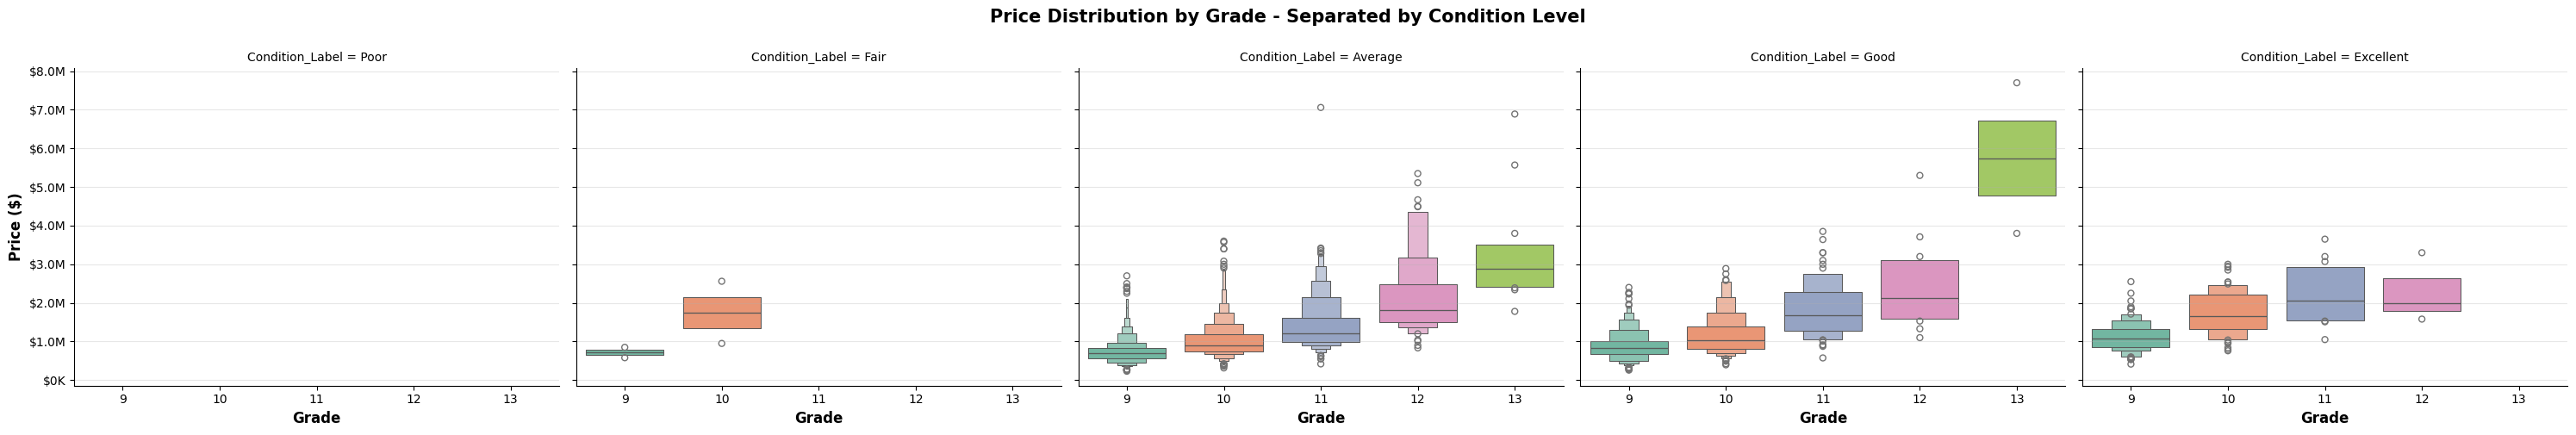

In [ ]:
# --- SEABORN PLOT 5: Catplot (Facet Grid) - Side-by-side Condition Comparison ---

condition_map = {1: 'Poor', 2: 'Fair', 3: 'Average', 4: 'Good', 5: 'Excellent'}
df_cat = df_all[(df_all['grade'] >= 9) & (df_all['grade'] <= 13)].copy()
df_cat['Condition_Label'] = df_cat['condition'].map(condition_map)

# Create catplot with subplots for each condition
g = sns.catplot(
    data=df_cat,
    x='grade',
    y='price',
    kind='boxen',  # violin alternative - better for skewed data
    col='Condition_Label',
    col_order=['Poor', 'Fair', 'Average', 'Good', 'Excellent'],
    palette='Set2',
    height=5,
    aspect=1.2,
    sharey=True
)

g.set_axis_labels('Grade', 'Price ($)', fontsize=12, fontweight='bold')
g.fig.suptitle('Price Distribution by Grade - Separated by Condition Level', 
               fontsize=15, fontweight='bold', y=1.00)

# Format y-axis
for ax in g.axes.flat:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1e6:.1f}M' if x >= 1e6 else f'${x/1e3:.0f}K'))
    ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

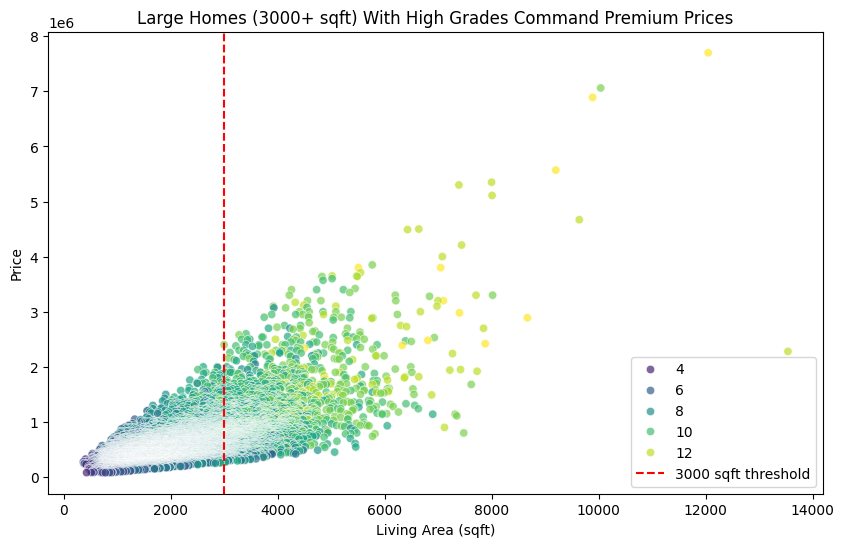

In [142]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df_all,
    x='sqft_living',
    y='price',
    hue='grade',
    palette='viridis',
    alpha=0.7
)

plt.axvline(3000, color='red', linestyle='--', label='3000 sqft threshold')
plt.title("Large Homes (3000+ sqft) With High Grades Command Premium Prices")
plt.xlabel("Living Area (sqft)")
plt.ylabel("Price")
plt.legend()
plt.show()

In [149]:
tier = df_all[(df_all['grade'] >= 9) & (df_all['condition'] > 4) & (df_all['sqft_living'] > 3000)].copy()
len(tier)
print(f":${tier['price'].mean():,.0f}")

:$1,592,715


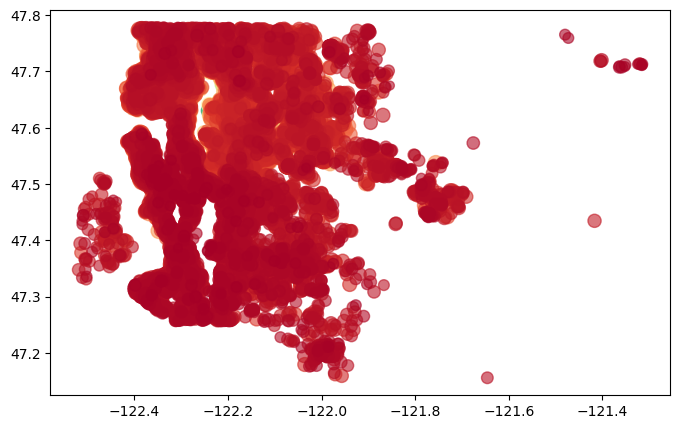

In [8]:
plt.scatter(df_all['long'], df_all['lat'], c=df_all['price'], s=df_all['grade']*10, 
            cmap='RdYlGn', alpha=0.6)

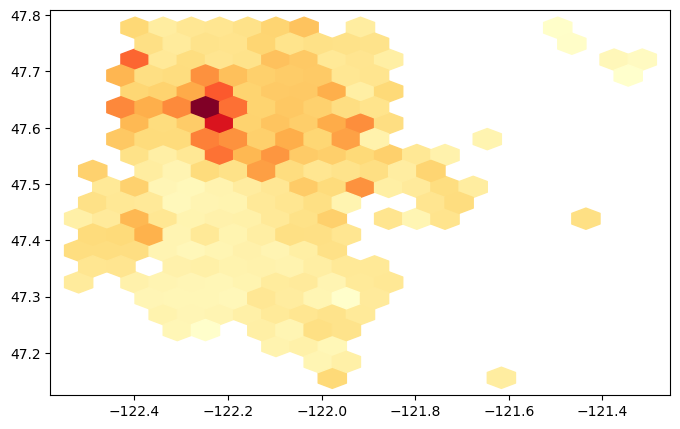

In [9]:
plt.hexbin(df_all['long'], df_all['lat'], C=df_all['price'], gridsize=20, cmap='YlOrRd')

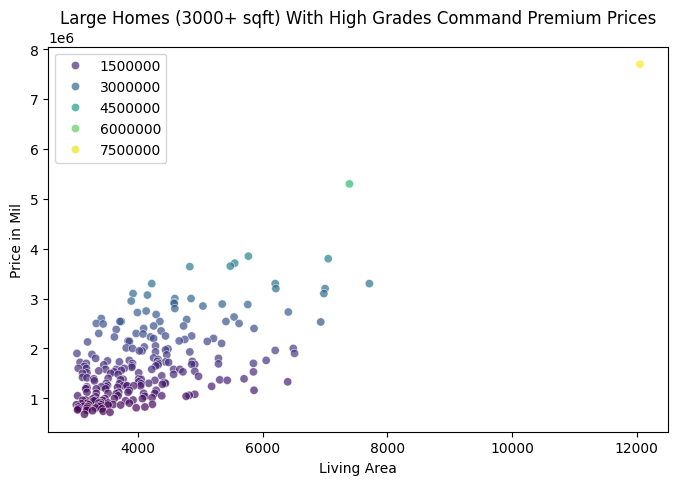

In [36]:
df_besths = df_all[(df_all['grade'] >= 10) & (df_all['condition'] >= 4) & (df_all['sqft_living'] >= 3000) & (df_all['long'] <= -122.0)& (df_all['lat'] >= 47.5)].copy()
sns.scatterplot(
    data=df_besths,
    x='sqft_living',
    y='price',
    hue='price',
    palette='viridis',
    alpha=0.7
)

#plt.axvline(3000, color='red', linestyle='--', label='3000 sqft threshold')
plt.title("Large Homes (3000+ sqft) With High Grades Command Premium Prices")
plt.xlabel("Living Area")
plt.ylabel("Price in Mil")
plt.legend()
plt.show()

<Axes: xlabel='long', ylabel='lat'>

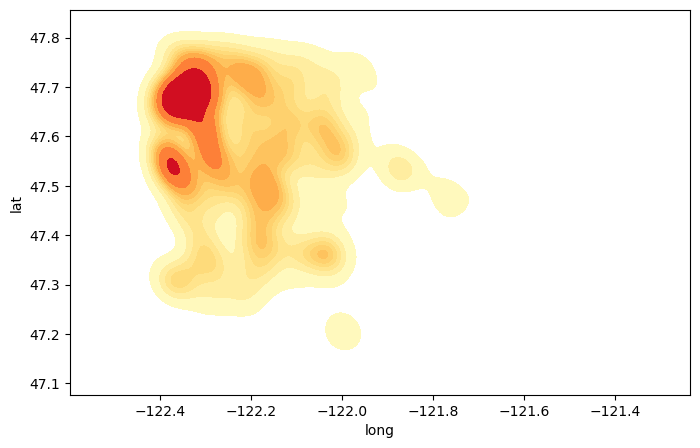

In [14]:
#plt.figure(figsize=(10,6))
sns.kdeplot(data=df_all, x='long', y='lat', cmap='YlOrRd', fill=True)

In [ ]:
# --- SUMMARY & RECOMMENDATIONS FOR JENNIFER ---

print(f"""
✓ HYPOTHESIS 1: Grade & Condition Premium
  - High grade (10-13) + Good condition (4-5) = Highest prices
  - Broader market availability
  - Jennifer can find luxury properties anywhere in the county

✓ HYPOTHESIS 2: Size + Grade = Premium
  - Large homes (3000+ sqft) with high grades command premium prices
  - Spacious + High Quality = Luxury Appeal
  - Perfect for someone who wants to "show off"
  - Attracts wealthy buyers in resale market

✓ HYPOTHESIS 3: Luxury Package (Multi-Factor)
  - Combining Grade 10+, Condition 4+, Size 3000+ = True Luxury Segment
  - Premium Luxury properties available
  - Average Price: $?
  - These are the HOTTEST resale items for wealthy buyers

JENNIFER'S BEST STRATEGY:
Target Tier 2 Premium Luxury properties:
  • Grade: 11+
  • Condition: 4+ (Good/Excellent)
  • Size: 3000+ sqft (spacious, impressive)
  • Price: $M
  • Properties available: 
  
These properties have STRONG RESALE potential and appeal to luxury buyers
""")



REVISED HYPOTHESES SUMMARY - NO WATERFRONT REQUIRED


NameError: name 'tier2' is not defined